### ML Classification and Model Evaluation

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score,roc_auc_score, confusion_matrix

In [3]:
titanic = pd.read_csv("/Users/sanasalim/Downloads/Linkific/Day 8/Titanic-Dataset.csv")

In [6]:
titanic.shape

(891, 12)

In [7]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
titanic.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [4]:
target = "Survived"
features = ["Pclass","Sex","Age","SibSp","Parch","Fare","Embarked"]
X = titanic[features]
y = titanic[target]

In [5]:
X['Age'].fillna(X['Age'].median(),inplace=True)
X['Embarked'].fillna(X['Embarked'].mode()[0],inplace=True)

/var/folders/t_/1r0rf0nj71lbvfn8t13yq0zc0000gn/T/ipykernel_59994/3633436932.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['Age'].fillna(X['Age'].median(),inplace=True)
/var/folders/t_/1r0rf0nj71lbvfn8t13yq0zc0000gn/T/ipykernel_59994/3633436932.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Age'].fillna(X['Age'].median(),inplace

In [13]:
X.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [10]:
# encountered error during training: "could not convert string to float:male"
# encode categoricalvariables
X['Sex'] = LabelEncoder().fit_transform(X['Sex'])        
X['Embarked'] = LabelEncoder().fit_transform(X['Embarked'])  
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42, stratify=y)

/var/folders/t_/1r0rf0nj71lbvfn8t13yq0zc0000gn/T/ipykernel_59994/1069991918.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Sex'] = LabelEncoder().fit_transform(X['Sex'])
/var/folders/t_/1r0rf0nj71lbvfn8t13yq0zc0000gn/T/ipykernel_59994/1069991918.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Embarked'] = LabelEncoder().fit_transform(X['Embarked'])


In [11]:
print(X.dtypes)

Pclass        int64
Sex           int64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked      int64
dtype: object


In [12]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train,y_train)
log_pred  = log_reg.predict(X_test)
log_prob  = log_reg.predict_proba(X_test)[:, 1]

dec_tree = DecisionTreeClassifier(max_depth=5,random_state=42)
dec_tree.fit(X_train,y_train)
tree_pred  = dec_tree.predict(X_test)
tree_prob  = dec_tree.predict_proba(X_test)[:, 1]

random = RandomForestClassifier(max_depth=5, random_state=42)
random.fit(X_train,y_train)
random_pred  = random.predict(X_test)
random_prob  = random.predict_proba(X_test)[:, 1]

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train,y_train)
knn_pred  = knn.predict(X_test)
knn_prob  = knn.predict_proba(X_test)[:, 1]

In [13]:
def compute_metrics(name, y_true, y_pred, y_prob):
    return {
        'Model':     name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall': round(recall_score(y_true, y_pred), 4),
        'F1-Score': round(f1_score(y_true, y_pred), 4)
        ,'ROC-AUC':  round(roc_auc_score(y_true, y_prob), 4),
    }
a = compute_metrics('Logistic Regression', y_test, log_pred, log_prob)
b = compute_metrics('Decision Tree', y_test, tree_pred, tree_prob)
c = compute_metrics('Random Forest', y_test, random_pred, random_prob)
d = compute_metrics('KNN', y_test, knn_pred, knn_prob)

results = [a,b,c,d]

results_df = pd.DataFrame(results).set_index('Model')
print("                      Model Comparison Table")
results_df

                      Model Comparison Table


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.8045,0.7931,0.6667,0.7244,0.8519
Decision Tree,0.7598,0.7407,0.5797,0.6504,0.7891
Random Forest,0.8101,0.8571,0.6087,0.7119,0.8502
KNN,0.6704,0.5833,0.5072,0.5426,0.6945


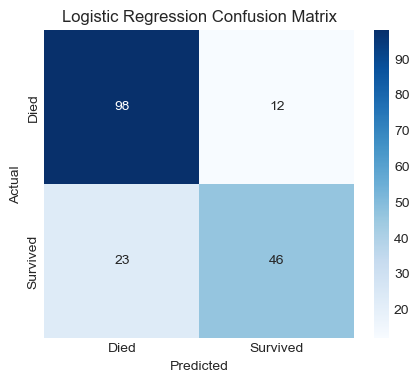

In [ ]:
cm = confusion_matrix(y_test, log_pred)

plt.figure(figsize=(5, 4))

sns.heatmap(cm,annot=True,cmap="Blues",xticklabels=["Died", "Survived"],yticklabels=["Died", "Survived"])
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

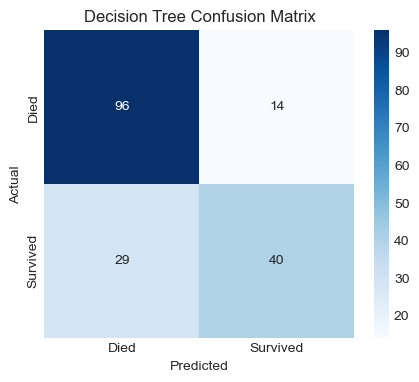

In [ ]:
cm = confusion_matrix(y_test, tree_pred)

plt.figure(figsize=(5, 4))

sns.heatmap(cm,annot=True,cmap="Blues",xticklabels=["Died", "Survived"],yticklabels=["Died", "Survived"])
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

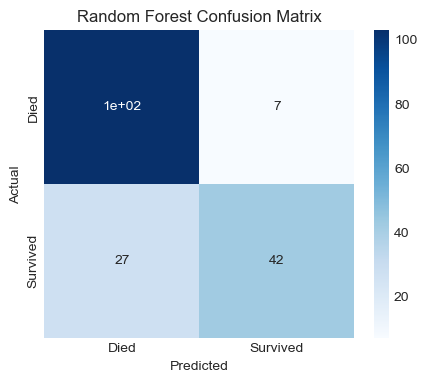

In [ ]:
cm = confusion_matrix(y_test, random_pred)

plt.figure(figsize=(5, 4))

sns.heatmap(cm,annot=True,cmap="Blues",xticklabels=["Died", "Survived"],yticklabels=["Died", "Survived"])
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

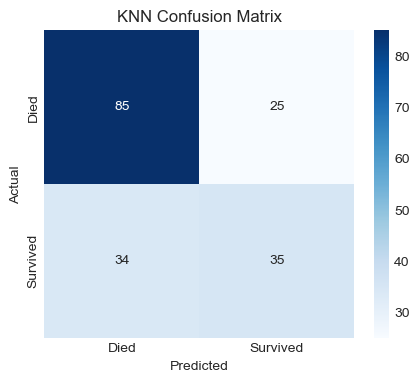

In [ ]:
cm = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(5, 4))

sns.heatmap(cm,annot=True,cmap="Blues",xticklabels=["Died", "Survived"],yticklabels=["Died", "Survived"])
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [14]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
log_score = cross_val_score(log_reg, X, y, cv=kfold, scoring='f1')
tree_score = cross_val_score(dec_tree, X, y, cv=kfold, scoring='f1')
random_score = cross_val_score(random, X, y, cv=kfold, scoring='f1')
knn_score = cross_val_score(knn, X, y, cv=kfold, scoring='f1')

In [20]:
cv_results = [log_score,tree_score,random_score,knn_score]
cv_results_df = pd.DataFrame(cv_results)
print("                      Model Comparison Table")
cv_results_df
print("Logistic Regression Scores:\n",log_score)
print("Decision Tree Scores:\n",tree_score)
print("Random Forest Scores:\n",random_score)
print("KNN Scores:\n",knn_score)

                      Model Comparison Table
Logistic Regression Scores:
 [0.7        0.72868217 0.704      0.71532847 0.77372263]
Decision Tree Scores:
 [0.76335878 0.72727273 0.68333333 0.74015748 0.7079646 ]
Random Forest Scores:
 [0.79032258 0.73170732 0.71186441 0.76422764 0.74782609]
KNN Scores:
 [0.65079365 0.64233577 0.58914729 0.609375   0.59701493]
